## Differential Gene Expression Analyse (TCGA BRCA & LUAD) with pydeseq2


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from pydeseq2.default_inference import DefaultInference


## Read and process data and metadata files

In [3]:
import os
filepath = "C:\\Users\\HP\\Documents\\Project\\transcriptome_profiling"
os.chdir(filepath)

counts = pd.read_csv("rna_seq_counts.csv", index_col=0)
meta = pd.read_csv("rna_seq_metadata.csv")

# Metadata mit 'File Name' als Index versehen, damit sie zum Index von 'counts' passt
meta = meta.set_index("File Name")

print("counts:", counts.shape)
print("meta:  ", meta.shape)
counts.columns = counts.columns.str.replace(' ','_')
meta.columns = meta.columns.str.replace(' ','_')

# Reihenfolge/Uebereinstimmung der Samples pruefen und angleichen
assert set(counts.index) == set(meta.index), "Sample-IDs stimmen zwischen beiden Dateien nicht ueberein!"
meta = meta.loc[counts.index]




counts: (57, 60660)
meta:   (57, 11)


In [4]:
#checks if counts are all integers
counts_int = counts.round(0).astype(int)

# Sanity check: keine negativen Werte
assert (counts_int.values >= 0).all()
counts_int.head()

,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,AL451106.1,AC092910.4,AC073611.1,AC136977.1,AC078856.1,AC008763.4,AL592295.6,AC006486.3,AL391628.1,AP006621.6
sample_name,,,,,,,,,,,,,,,,,,,,,
032e5aa7-8028-48ad-8fe4-6a5cc6aee5cb,75,0,90,19,6,7,24,51,7,18,...,0,0,0,0,0,0,10,0,0,2
068ba2ae-288c-446d-8d17-72445ce4f788,55,0,127,11,12,18,52,44,18,47,...,0,0,1,0,0,0,14,0,0,1
08429604-2dc7-4827-8ba5-80818aa45a51,30,4,90,10,5,14,100,49,17,43,...,0,0,0,0,0,0,7,0,0,1
09c3168a-9886-4095-a5ef-8bdcd0988dea,56,1,88,15,8,8,8,46,41,33,...,0,0,0,0,0,0,24,0,0,1
13fc37db-3160-4e82-bd63-52fc295e0e19,95,0,110,22,10,4,12,54,7,60,...,0,0,0,0,0,0,20,0,0,1


In [5]:
def run_deseq2_for_project(project_id, counts_df, meta_df, min_total_count=10):
    """Fuehrt eine DESeq2-DGE-Analyse (Tumor vs. Normal) fuer ein einzelnes TCGA-Projekt durch."""

    sub_meta = meta_df.loc[meta_df["Project_ID"] == project_id].copy()
    sub_counts = counts_df.loc[sub_meta.index]

    print(f"\n=== {project_id} ===")
    print(sub_meta["Tissue_Type"].value_counts())

    # Design-Faktor als kategorische Variable mit 'Normal' als Referenzlevel
    sub_meta["Tissue_Type"] = pd.Categorical(
        sub_meta["Tissue_Type"], categories=["Normal", "Tumor"]
    )

    # Low-count Gene rausfiltern
    keep = sub_counts.sum(axis=0) >= min_total_count
    sub_counts = sub_counts.loc[:, keep]
    print(f"Gene nach Filter (Summe >= {min_total_count}): {sub_counts.shape[1]} von {counts_df.shape[1]}")

    inference = DefaultInference(n_cpus=4)
    dds = DeseqDataSet(
        counts=sub_counts,
        metadata=sub_meta,
        design="~Tissue_Type",
        refit_cooks=True,
        inference=inference,
    )
    dds.deseq2()

    stat_res = DeseqStats(
        dds,
        contrast=["Tissue_Type", "Tumor", "Normal"],
        inference=inference,
    )
    stat_res.summary()

    results_df = stat_res.results_df.sort_values("padj")
    return dds, stat_res, results_df


## Analysis for TCGA-BRCA


In [7]:
dds_brca, stat_brca, res_brca = run_deseq2_for_project("TCGA-BRCA", counts_int, meta)
res_brca.head(20)



=== TCGA-BRCA ===
Tissue_Type
Tumor     27
Normal     3
Name: count, dtype: int64
Gene nach Filter (Summe >= 10): 28852 von 60660
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.19 seconds.

Fitting dispersions...
... done in 30.14 seconds.

Fitting dispersion trend curve...
... done in 2.56 seconds.

Fitting MAP dispersions...
... done in 40.77 seconds.

Fitting LFCs...
... done in 19.24 seconds.

Calculating cook's distance...
... done in 0.12 seconds.

Replacing 3442 outlier genes.

Fitting dispersions...
... done in 2.20 seconds.

Fitting MAP dispersions...
... done in 2.53 seconds.

Fitting LFCs...
... done in 2.25 seconds.

Running Wald tests...
... done in 6.75 seconds.



Log2 fold change & Wald test p-value: Tissue_Type Tumor vs Normal
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
TSPAN6       37.483835       -0.714417  0.489630 -1.459095  0.144539  0.704604
TNMD          5.009903       -5.091138  1.185475 -4.294597  0.000018  0.002123
DPM1        100.304638        0.421644  0.304797  1.383360  0.166554  0.734855
SCYL3        14.515781        0.778938  0.426967  1.824350  0.068099  0.531846
C1orf112      7.299893        1.454193  0.598160  2.431110  0.015053  0.246561
...                ...             ...       ...       ...       ...       ...
AL133351.4    1.776673       -0.331816  0.718858 -0.461587  0.644377  0.934394
AC092910.4    0.927875        0.431308  2.759755  0.156285  0.875809  0.977212
AC078856.1    0.382208        0.734546  5.212231  0.140927  0.887927       NaN
AL592295.6   15.043277        0.116622  0.417248  0.279501  0.779860  0.960966
AP006621.6    1.289404        0.835569  1.194946  0.699253  0.484

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
VEGFD,8.513559,-5.867822,0.684479,-8.572680,1.011039e-17,2.109837e-13
GPAM,35.315734,-4.492160,0.634212,-7.083054,1.410116e-12,1.471315e-08
KCNMB1,4.508508,-2.894891,0.412245,-7.022261,2.183062e-12,1.518538e-08
ACSS2,34.618955,-2.022521,0.295330,-6.848342,7.471081e-12,3.897663e-08
GSN,196.163453,-2.777298,0.427492,-6.496721,8.208945e-11,3.426085e-07
MMP11,270.215761,5.283090,0.818046,6.458180,1.059695e-10,3.685620e-07
LPL,160.769135,-5.409262,0.846249,-6.392047,1.636791e-10,4.879509e-07
SIK2,23.561726,-2.599035,0.408056,-6.369309,1.898811e-10,4.953049e-07
MAMDC2,5.518369,-2.851077,0.450908,-6.322965,2.565916e-10,5.949503e-07
KLHL13,5.136188,-3.452453,0.559133,-6.174655,6.630824e-10,1.153100e-06


## 5. Analysis for TCGA-LUAD


In [8]:
dds_luad, stat_luad, res_luad = run_deseq2_for_project("TCGA-LUAD", counts_int, meta)
res_luad.head(20)



=== TCGA-LUAD ===
Tissue_Type
Tumor     23
Normal     4
Name: count, dtype: int64
Gene nach Filter (Summe >= 10): 23892 von 60660
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.08 seconds.

Fitting dispersions...
... done in 18.92 seconds.

Fitting dispersion trend curve...
... done in 1.83 seconds.

Fitting MAP dispersions...
... done in 28.32 seconds.

Fitting LFCs...
... done in 14.07 seconds.

Calculating cook's distance...
... done in 0.13 seconds.

Replacing 862 outlier genes.

Fitting dispersions...
... done in 0.83 seconds.

Fitting MAP dispersions...
... done in 0.81 seconds.

Fitting LFCs...
... done in 0.70 seconds.

Running Wald tests...
... done in 5.36 seconds.



Log2 fold change & Wald test p-value: Tissue_Type Tumor vs Normal
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
TSPAN6      56.329363        1.568116  0.393463  3.985419  0.000067  0.001557
DPM1        89.493964        0.222854  0.242573  0.918709  0.358248  0.599634
SCYL3        7.411141        0.504016  0.365894  1.377491  0.168360  0.403780
C1orf112     4.097813        1.917262  0.722831  2.652436  0.007991  0.060313
FGR         27.797984       -2.221405  0.491106 -4.523274  0.000006  0.000226
...               ...             ...       ...       ...       ...       ...
AL133351.4   1.410530        1.057719  0.929533  1.137903  0.255161  0.502590
LNCDAT       0.716717        2.201006  2.497515  0.881279  0.378167       NaN
AC010980.1   0.626685       -0.272293  1.107094 -0.245953  0.805718       NaN
AL592295.6  10.619438        0.422236  0.383259  1.101699  0.270593  0.517753
AP006621.6   0.589839        1.882722  1.807344  1.041707  0.297548       Na

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
RTKN2,19.984543,-5.223227,0.394938,-13.225448,6.256307e-40,1.167239e-35
PRX,11.545109,-3.911857,0.324196,-12.066326,1.590796e-33,1.483974e-29
LGI3,12.380868,-6.868164,0.606349,-11.327083,9.636071e-30,5.992673e-26
TNNC1,50.092577,-4.762018,0.436609,-10.906832,1.069172e-27,4.986888e-24
KANK3,6.957012,-3.080869,0.314661,-9.791076,1.229801e-22,4.588878e-19
GPM6A,5.682367,-6.626346,0.681501,-9.723166,2.401949e-22,7.468859e-19
SEMA3G,13.590537,-3.660289,0.387350,-9.449567,3.402349e-21,7.934704e-18
PRKCE,8.017830,-2.579583,0.272913,-9.452032,3.323148e-21,7.934704e-18
KCNK3,8.869585,-3.758994,0.401373,-9.365336,7.580859e-21,1.571512e-17
CPB2,4.951400,-5.771646,0.617212,-9.351155,8.669590e-21,1.617485e-17


## Save the resluts


In [10]:
res_brca.to_csv("deseq2_results_BRCA.csv")
res_luad.to_csv("deseq2_results_LUAD.csv")
print("Gespeichert: deseq2_results_BRCA.csv, deseq2_results_LUAD.csv")


Gespeichert: deseq2_results_BRCA.csv, deseq2_results_LUAD.csv


## Volcano Plots of each experimenatal condition

TCGA-BRCA: 503 signifikante Gene (padj < 0.05, |log2FC| > 1.0) von 20868 getesteten Genen


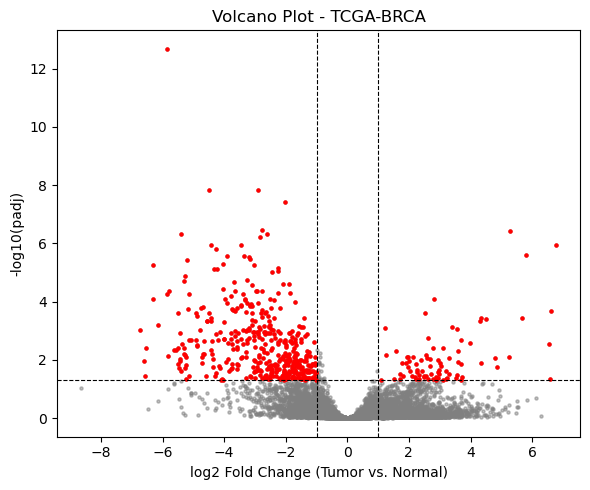

TCGA-LUAD: 1989 signifikante Gene (padj < 0.05, |log2FC| > 1.0) von 18657 getesteten Genen


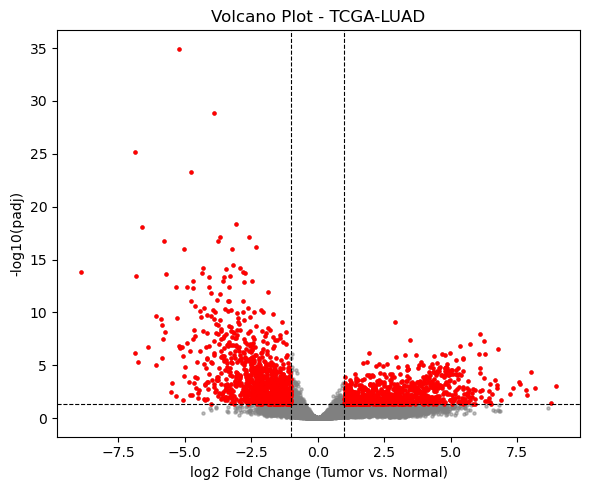

In [11]:
def summarize_and_plot(results_df, project_name, padj_cutoff=0.05, lfc_cutoff=1.0):
    # constructs new data frame containing only significant genes
    df = results_df.dropna(subset=["padj"]).copy()
    sig = df[(df["padj"] < padj_cutoff) & (df["log2FoldChange"].abs() > lfc_cutoff)]
    print(f"{project_name}: {len(sig)} signifikante Gene "
          f"(padj < {padj_cutoff}, |log2FC| > {lfc_cutoff}) von {len(df)} getesteten Genen")
    # constructs volcano plor basen on the previously generated results
    plt.figure(figsize=(6, 5))
    plt.scatter(df["log2FoldChange"], -np.log10(df["padj"]), s=5, color="grey", alpha=0.5)
    plt.scatter(sig["log2FoldChange"], -np.log10(sig["padj"]), s=5, color="red")
    plt.axvline(lfc_cutoff, color="black", linestyle="--", linewidth=0.8)
    plt.axvline(-lfc_cutoff, color="black", linestyle="--", linewidth=0.8)
    plt.axhline(-np.log10(padj_cutoff), color="black", linestyle="--", linewidth=0.8)
    plt.xlabel("log2 Fold Change (Tumor vs. Normal)")
    plt.ylabel("-log10(padj)")
    plt.title(f"Volcano Plot - {project_name}")
    plt.tight_layout()
    plt.show()

    return sig

sig_brca = summarize_and_plot(res_brca, "TCGA-BRCA")
sig_luad = summarize_and_plot(res_luad, "TCGA-LUAD")


## Summary for each result

In [36]:
print(f'BRCA number of significant genes: {sig_brca.shape[0]}')
print(f'BRCA number of upregulated genes: {sig_brca[sig_brca['log2FoldChange'] > 0].shape[0]}')
print(f'BRCA number of downregulated genes: {sig_brca[sig_brca['log2FoldChange'] < 0].shape[0]}')

print(f"LUAD number of significant genes: {sig_luad.shape[0]}")
print(f'LUAD number of upregulated genes: {sig_luad[sig_luad['log2FoldChange'] > 0].shape[0]}')
print(f'LUAD number of downregulated genes: {sig_luad[sig_luad['log2FoldChange'] < 0].shape[0]}')

BRCA number of significant genes: 503
BRCA number of upregulated genes: 81
BRCA number of downregulated genes: 422
LUAD number of significant genes: 1989
LUAD number of upregulated genes: 903
LUAD number of downregulated genes: 1086


In [28]:
sig_brca.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
VEGFD,8.513559,-5.867822,0.684479,-8.572680,1.011039e-17,2.109837e-13
GPAM,35.315734,-4.492160,0.634212,-7.083054,1.410116e-12,1.471315e-08
KCNMB1,4.508508,-2.894891,0.412245,-7.022261,2.183062e-12,1.518538e-08
ACSS2,34.618955,-2.022521,0.295330,-6.848342,7.471081e-12,3.897663e-08
GSN,196.163453,-2.777298,0.427492,-6.496721,8.208945e-11,3.426085e-07


In [34]:
sig_brca[sig_brca['log2FoldChange'] > 0].shape[0]


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
MMP11,270.215761,5.283090,0.818046,6.458180,1.059695e-10,3.685620e-07
COL10A1,200.031012,6.782616,1.095290,6.192529,5.920630e-10,1.153100e-06
COMP,183.754929,5.800222,0.962300,6.027456,1.665607e-09,2.482707e-06
CTHRC1,209.618164,2.830107,0.543601,5.206217,1.927290e-07,8.230505e-05
COL11A1,124.531211,6.628132,1.340314,4.945208,7.606260e-07,2.144965e-04
...,...,...,...,...,...,...
MMP1,33.340241,6.575346,2.019759,3.255510,1.131888e-03,4.640518e-02
ASPM,11.502413,3.678173,1.133625,3.244611,1.176112e-03,4.774923e-02
MATN3,26.480339,3.108855,0.959374,3.240504,1.193186e-03,4.816133e-02
H2AZ1,199.523140,1.102155,0.340590,3.236013,1.212118e-03,4.873697e-02
